### Name : ASHIF ALI

Enrollment no : 23SOECE11085

Rollno : 02

Division : C

Branch : CE

Subject code : CE628

Subject name : AIML

#### 1.1 Give difference between Best First Search and A* algorithm (1 Marks)
You need to work with iris.csv. Fetch the first 5 and last 5 rows. Find no. of
columns and rows from the dataset. Is there any missing value? If yes, deal
with it. Find type of given data. Find Statistical description. Create a new
column based on some condition. (4 Marks)
Thoughtful Question: How does Pandas internally represent missing data
(NaN), and what is its impact on mathematical operations?

Best First Search chooses nodes based only on heuristic distance, while A* considers actual path cost + heuristic, making it more reliable for optimal solutions.

In [44]:
import pandas as pd
import numpy as np

In [45]:
from sklearn.datasets import load_iris
iris= load_iris()
df= pd.DataFrame(iris.data, columns=iris.feature_names)
df['species']=iris.target

In [46]:
print("First 5 rows:")
print(df.head())


First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  


In [47]:
print("\nLast 5 rows:")
print(df.tail())


Last 5 rows:
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.1               1.8   

     species  
145        2  
146        2  
147        2  
148        2  
149        2  


In [48]:

print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


In [49]:
df = df.dropna()  

print("\nData Types:")
print(df.dtypes)


Data Types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int64
dtype: object


In [50]:
print("\nStatistical Description:")
print(df.describe())


Statistical Description:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)     species  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [52]:
df['Petal_Size'] = np.where(df['petal length (cm)'] > 3, "Large", "Small")

NaN is a special floating-point value used to indicate missing or undefined data.

If a column originally contains integers but a missing value appears, Pandas often converts the column to float, because NaN exists only in floating-point format.

In object columns, missing values may also appear as None, but Pandas typically treats them similarly to NaN.

#### Spam Detection (Random Forest vs. AdaBoost) Build both a Random Forest
and an AdaBoost classifier to classify spam emails and benchmark their
performance on a test set. create a comparative table of accuracy, precision,
and recall for both ensemble methods and evaluate their training and testing
times. conclude which method is more effective for this specific binary
classification problem.
Thoughtful Question: Does a Random Forest train its trees independently or
one after another?

In [53]:
import pandas as pd
import numpy as np

In [54]:
data=pd.read_csv("spambase.csv")

In [55]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_req_our                4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 

In [56]:
import pandas as pd
import time
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score


df = pd.read_csv("spambase.csv")

In [57]:
df.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_req_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [58]:
df.isnull()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_req_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4596,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4597,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4598,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4599,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [59]:
df.describe()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_req_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
count,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,...,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000
mean,0.104553,0.213015,0.280656,0.065425,0.312223,0.095901,0.114208,0.105295,0.090067,0.239413,...,0.038575,0.139030,0.016976,0.269071,0.075811,0.044238,5.191515,52.172789,283.289285,0.394045
std,0.305358,1.290575,0.504143,1.395151,0.672513,0.273824,0.391441,0.401071,0.278616,0.644755,...,0.243471,0.270355,0.109394,0.815672,0.245882,0.429342,31.729449,194.891310,606.347851,0.488698
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.588000,6.000000,35.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.065000,0.000000,0.000000,0.000000,0.000000,2.276000,15.000000,95.000000,0.000000
75%,0.000000,0.000000,0.420000,0.000000,0.380000,0.000000,0.000000,0.000000,0.000000,0.160000,...,0.000000,0.188000,0.000000,0.315000,0.052000,0.000000,3.706000,43.000000,266.000000,1.000000
max,4.540000,14.280000,5.100000,42.810000,10.000000,5.880000,7.270000,11.110000,5.260000,18.180000,...,4.385000,9.752000,4.081000,32.478000,6.003000,19.829000,1102.500000,9989.000000,15841.000000,1.000000


In [60]:
X = df.drop("spam", axis=1)
y = df["spam"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [61]:

rf = RandomForestClassifier(n_estimators=100, random_state=42)
start = time.time()
rf.fit(X_train, y_train)
rf_train_time = time.time() - start

start = time.time()
rf_pred = rf.predict(X_test)
rf_test_time = time.time() - start

In [62]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)


In [63]:
ada = AdaBoostClassifier(n_estimators=100, random_state=42)

start = time.time()
ada.fit(X_train, y_train)
ada_train_time = time.time() - start

In [64]:
start = time.time()
ada_pred = ada.predict(X_test)
ada_test_time = time.time() - start

In [65]:
ada_accuracy = accuracy_score(y_test, ada_pred)
ada_precision = precision_score(y_test, ada_pred)
ada_recall = recall_score(y_test, ada_pred)


In [66]:
results = pd.DataFrame({
    "Model": ["Random Forest", "AdaBoost"],
    "Accuracy": [rf_accuracy, ada_accuracy],
    "Precision": [rf_precision, ada_precision],
    "Recall": [rf_recall, ada_recall],
    "Training Time": [rf_train_time, ada_train_time],
    "Testing Time": [rf_test_time, ada_test_time]
})

print(results)

           Model  Accuracy  Precision    Recall  Training Time  Testing Time
0  Random Forest  0.955483   0.975477  0.917949       1.109968      0.037947
1       AdaBoost  0.937025   0.948649  0.900000       1.215990      0.043165


#### Use iris.csv. Import necessary files to implement classification. Apply label
encoding with suitable columns. Visualize data distribution using seaborn -
pairplot. Implement suitable classification.
Thoughtful Question: How does SVM work?

In [67]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [68]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv("iris.csv")

In [69]:
print("First 5 rows:\n", df.head())


le = LabelEncoder()
df['Species'] = le.fit_transform(df['Species'])

First 5 rows:
    Sepal.Length  Sepal.Width  Petal.Length  Petal.Width Species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [70]:
print("\nAfter Label Encoding:\n", df.head())


After Label Encoding:
    Sepal.Length  Sepal.Width  Petal.Length  Petal.Width  Species
0           5.1          3.5           1.4          0.2        0
1           4.9          3.0           1.4          0.2        0
2           4.7          3.2           1.3          0.2        0
3           4.6          3.1           1.5          0.2        0
4           5.0          3.6           1.4          0.2        0


In [78]:
df.tail()

,age,education.num,capital.gain,hours.per.week,income
32556,22,10,0,40,<=50K
32557,27,12,0,38,<=50K
32558,40,9,0,40,>50K
32559,58,9,0,40,<=50K
32560,22,9,0,20,<=50K


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   education.num   32561 non-null  int64 
 2   capital.gain    32561 non-null  int64 
 3   hours.per.week  32561 non-null  int64 
 4   income          32561 non-null  object
dtypes: int64(4), object(1)
memory usage: 1.2+ MB


In [80]:
df.isnull()

,age,education.num,capital.gain,hours.per.week,income
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
32556,False,False,False,False,False
32557,False,False,False,False,False
32558,False,False,False,False,False
32559,False,False,False,False,False


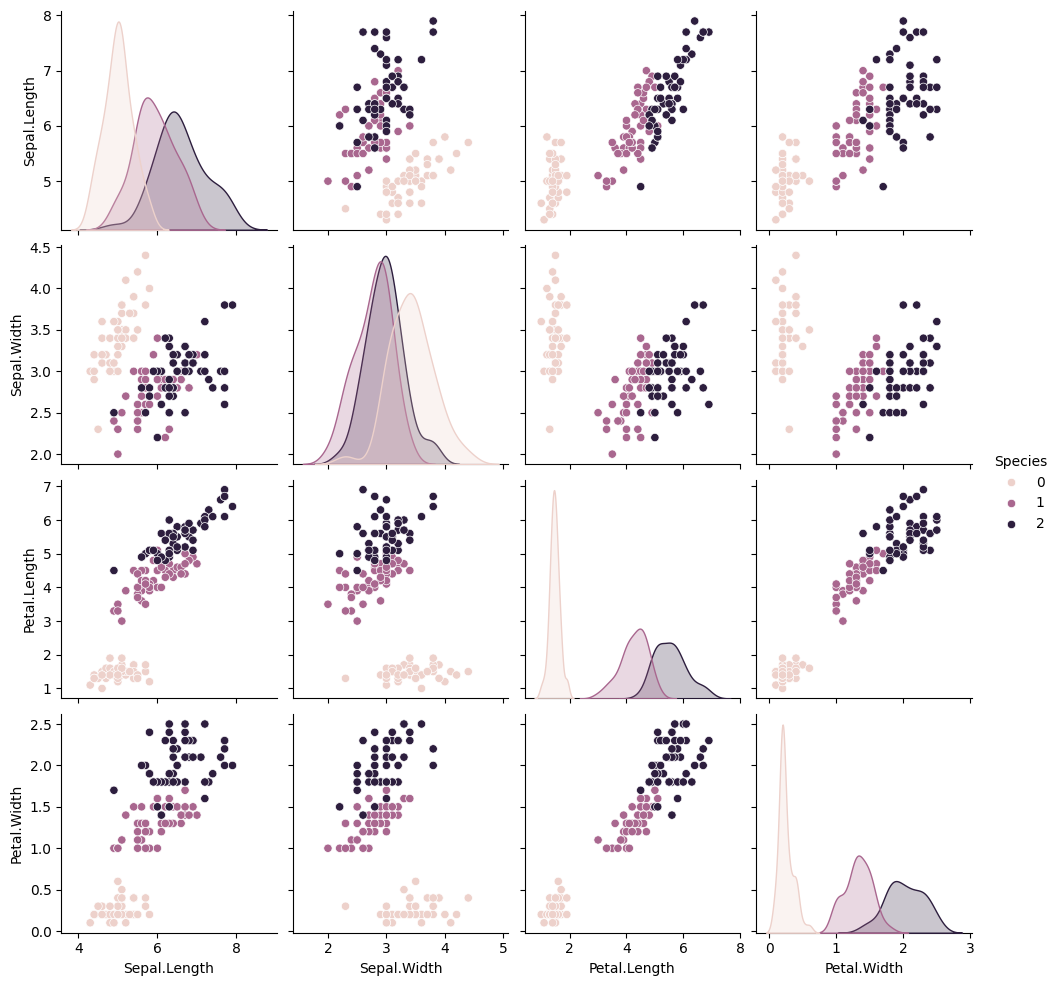

In [71]:

sns.pairplot(df, hue='Species')
plt.show()


In [72]:
X = df.drop('Species', axis=1)
y = df['Species']

In [73]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [74]:
model = SVC(kernel='linear')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [75]:
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



#### Import the salary dataset and perform a split into training and testing sets in
an 80:20 ratio. Develop a suitable model to predict salary based on years of
experience, and then evaluate the model&#39;s accuracy on the test set using
Mean Squared Error and R^2 score. Finally, create a visual representation of
both the training and testing results to demonstrate the linear relationship.
Thoughtful Question: How does a single extreme value (outlier) change the
direction of your regression line?

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

df=pd.read_csv('salary.csv')

X=df.iloc[:,0:1]
y=df.iloc[:,1]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

model=LinearRegression()
model.fit(X_train,y_train)

y_pred=model.predict(X_test)

print("MSE:",mean_squared_error(y_test,y_pred))
print("R2 Score:",r2_score(y_test,y_pred))



MSE: 6.659074262858444
R2 Score: 0.0011573049090530807
